In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf 

from tensorflow import keras
from tensorflow.keras import layers


In [2]:
data_train_path = "D:/Image_Classification_Model/Flower_Dataset/train"
data_test_path = "D:/Image_Classification_Model/Flower_Dataset/test"
data_val_path = "D:/Image_Classification_Model/Flower_Dataset/validation"


In [3]:
img_width = 180
img_height = 180 

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory (
    data_train_path ,
    shuffle = True,
    image_size = (img_width, img_height),
    batch_size = 32,
    validation_split= False)

Found 3500 files belonging to 5 classes.


In [5]:
data_train.class_names

['lily', 'lotus', 'orchid', 'sunflower', 'tulip']

In [6]:
data_cat = data_train.class_names

In [103]:
data_cat 

['lily', 'lotus', 'orchid', 'sunflower', 'tulip']

In [7]:
data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    image_size =(img_width, img_height),
    batch_size =32,
    shuffle=False,
    validation_split=False)

Found 750 files belonging to 5 classes.


In [8]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    image_size = (img_width, img_height),
    batch_size = 32,
    shuffle=False,
    validation_split=False)

Found 750 files belonging to 5 classes.


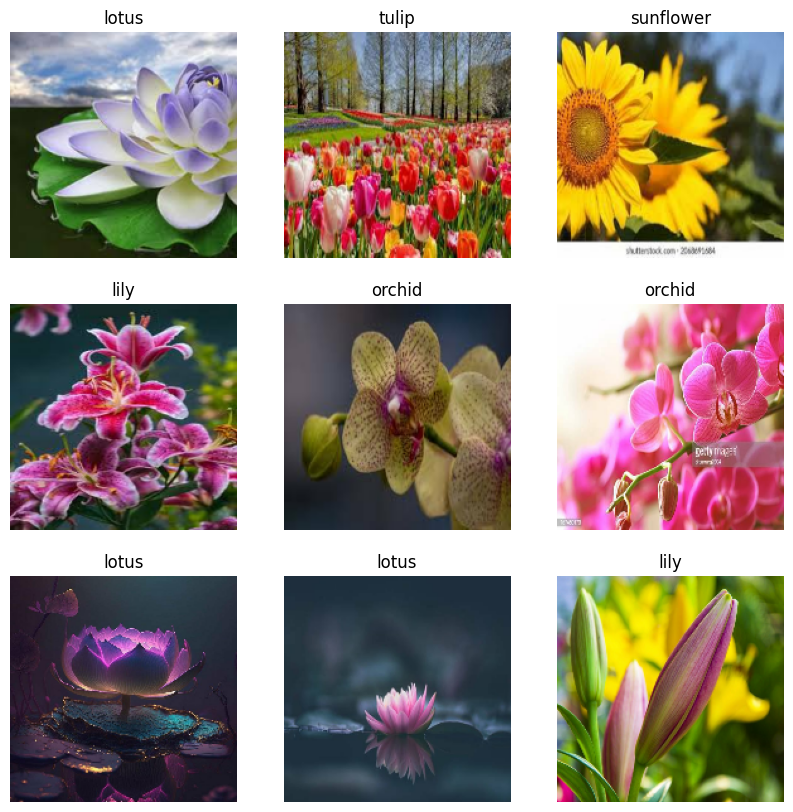

In [9]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [10]:
from tensorflow.keras.models import Sequential

In [11]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [12]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16,3, padding='same', activation= 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation= 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation= 'relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(units = len(data_cat))
    
])

In [13]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [14]:
epochs_size = 25 
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size )

Epoch 1/25


C:\Users\Mantasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


110/110 ━━━━━━━━━━━━━━━━━━━━ 95s 827ms/step - accuracy: 0.4703 - loss: 1.5057 - val_accuracy: 0.5520 - val_loss: 1.1465
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 127s 693ms/step - accuracy: 0.6317 - loss: 0.9616 - val_accuracy: 0.6280 - val_loss: 0.9205
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 50s 443ms/step - accuracy: 0.7489 - loss: 0.6851 - val_accuracy: 0.6987 - val_loss: 0.8440
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.8394 - loss: 0.4374 - val_accuracy: 0.7187 - val_loss: 0.9552
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.9037 - loss: 0.2993 - val_accuracy: 0.7547 - val_loss: 0.9538
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - accuracy: 0.9211 - loss: 0.2416 - val_accuracy: 0.7560 - val_loss: 0.9146
Epoch 7/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.9437 - loss: 0.1941 - val_accuracy: 0.7840 - val_loss: 0.8723
Epoch 8/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - accuracy: 0.9483 - loss: 0.1666 - va

Text(0.5, 1.0, 'Loss')

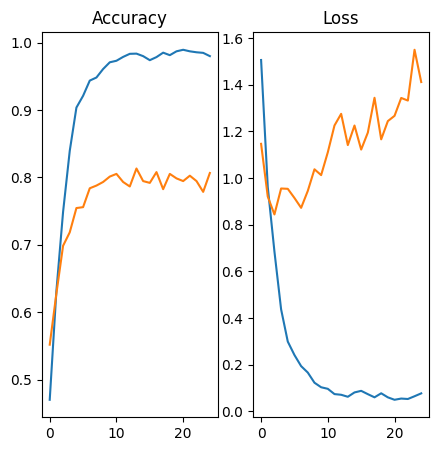

In [104]:
epochs_range = range(epochs_size)
plt.figure(figsize=(5,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation_Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation_Loss')
plt.title('Loss')

In [98]:
image = "D:/Image_Classification_Model/tulip.jpg"
image = tf.keras.utils.load_img(image, target_size=(img_width,img_height))
img_arr = tf.keras.utils.array_to_img(image)
img_bat = tf.expand_dims(img_arr,0)

In [99]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [100]:
score = tf.nn.softmax(predict)

In [101]:
print('Flower in Image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Flower in Image is tulip with accuracy of 100.00


In [ ]:
#lily1=100(lily)
#lily2=99.8(")
#lily3=100(")

#lotus1=99.9(lotus)
#lotus2=99.9(lotus)
#lotus3=97.8(lily)

#orchid=65.8(orchid)
#orchid2=96.1(orchid)
#orchid3=63.3(orchid)

#sunflwr=100(sunflr)
#sunflwer2=100(sunflr)
#sunflwer3=99.9(sunflr)

#tulip=100(tulip)
#tulip2=100(tulip)
#tulip3=95.9(tulip)


In [102]:
model.save('Image_classify.keras')